In [100]:
import os
import pandas as pd
import pmdarima as pm
from pmdarima import model_selection
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np
import warnings
import math
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

In [85]:
def cast_to_time(df):
    df['time'] = pd.to_datetime(df['time'])
    return df

In [86]:
data_dir = '../Data/Preprocessed'
base_paths = os.listdir(data_dir)
full_paths = [os.path.join(data_dir, p) for p in base_paths]
patients = {base_paths[i].split('.')[0] : cast_to_time(pd.read_csv(fp, sep=';')) for i, fp in enumerate(full_paths)}
ids = list(patients.keys())

In [87]:
too_long = ["HUPA0027P", "HUPA0028P", "HUPA0026P"]
for i in too_long:
    ids.remove(i)
    s = 1.5

In [88]:
warnings.filterwarnings("ignore")

# MAKE A FUNCTION

In [104]:
def get_metrics(order : tuple, test : int, t : int, patients : dict):
    metrics = []
    for i in ids:
        print(f"patient : {i}")
        ts = patients[i].loc[:, "glucose"]
        size = math.ceil(len(ts) * .2)
        print(size)
        train_data = ts.iloc[:-size]
        test_data = ts.iloc[-size:]
        tscv = TimeSeriesSplit(n_splits=5, test_size = test)

        # Store the Mean Squared Errors (MSE) from each fold
        mse_scores = []
        mape_scores = []
        r_2_scores = []
        fold_results = []
        f = 1

        # Convert the pandas Series to a numpy array for splitting
        X = train_data.values

        # Iterate through the splits
        for train_index, test_index in tscv.split(X):
            # Split the data
            cv_train = X[train_index]
            cv_test = X[test_index]


            cv_model = pm.ARIMA(order = order)
            cv_model.fit(cv_train)

            # --- Make Predictions on the Test Fold ---
            # The 'n_periods' is the length of the test set
            forecast, conf_int = cv_model.predict(n_periods=len(cv_test), return_conf_int=True)

            # --- Evaluate ---
            mse = mean_squared_error(cv_test, forecast)
            mape = mean_absolute_percentage_error(cv_test, forecast)
            r_2 = r2_score(cv_test, forecast)
            mse_scores.append(mse)
            mape_scores.append(mape)
            r_2_scores.append(r_2)
            # Store results for plotting
            fold_results.append({
                'train_data': train_data.iloc[train_index],
                'test_data': train_data.iloc[test_index],
                'forecast': pd.Series(forecast, index=train_data.index[test_index])
            })

            print(f"Fold: {f}")
            time.sleep(t/5)
            f += 1

        # Calculate and print the overall cross-validation score
        avg_mse = np.mean(mse_scores)
        avg_mape = np.mean(mape_scores)
        avg_r2 = np.mean(r_2_scores)
        metric = [avg_mse, avg_mape, avg_r2]
        print(f"\nAverage Cross-Validation MSE: {avg_mse:.2f}")
        print(f"\nAverage Cross-Validation MAPE: {avg_mape:.2f}")
        print(f"\nAverage Cross-Validation R2: {avg_r2:.2f}")
        
        metrics.append(metric)
        time.sleep(t/3)
    
    return metrics

## 15 min

In [106]:
p = 4
d = 0
q = 3

metrics_d0_15min = get_metrics(order = (p,d,q), test = 3, t = 1.2, patients = patients) # test = unit shfit, t = seconds

patient : HUPA0018P
779
Fold: 1
Fold: 2
Fold: 3
Fold: 4
Fold: 5

Average Cross-Validation MSE: 6.99

Average Cross-Validation MAPE: 0.04

Average Cross-Validation R2: -18.76
patient : HUPA0014P
766
Fold: 1
Fold: 2
Fold: 3
Fold: 4
Fold: 5

Average Cross-Validation MSE: 1.07

Average Cross-Validation MAPE: 0.00

Average Cross-Validation R2: -7.15
patient : HUPA0019P
743
Fold: 1
Fold: 2
Fold: 3
Fold: 4
Fold: 5

Average Cross-Validation MSE: 120.86

Average Cross-Validation MAPE: 0.07

Average Cross-Validation R2: -23.55
patient : HUPA0007P
772
Fold: 1
Fold: 2
Fold: 3
Fold: 4
Fold: 5

Average Cross-Validation MSE: 98.43

Average Cross-Validation MAPE: 0.09

Average Cross-Validation R2: -20.02
patient : HUPA0003P
754
Fold: 1
Fold: 2
Fold: 3
Fold: 4
Fold: 5

Average Cross-Validation MSE: 9.38

Average Cross-Validation MAPE: 0.03

Average Cross-Validation R2: -2.04
patient : HUPA0022P
805
Fold: 1
Fold: 2
Fold: 3
Fold: 4
Fold: 5

Average Cross-Validation MSE: 1.85

Average Cross-Validation MAP

In [107]:
p = 4
d = 1
q = 3

metrics_d1_15min = get_metrics(order = (p,d,q), test = 3, t = 1.2, patients = patients)

patient : HUPA0018P
779
Fold: 1
Fold: 2
Fold: 3
Fold: 4
Fold: 5

Average Cross-Validation MSE: 0.05

Average Cross-Validation MAPE: 0.00

Average Cross-Validation R2: 0.70
patient : HUPA0014P
766
Fold: 1
Fold: 2
Fold: 3
Fold: 4
Fold: 5

Average Cross-Validation MSE: 0.01

Average Cross-Validation MAPE: 0.00

Average Cross-Validation R2: 0.90
patient : HUPA0019P
743
Fold: 1
Fold: 2
Fold: 3
Fold: 4
Fold: 5

Average Cross-Validation MSE: 123.43

Average Cross-Validation MAPE: 0.09

Average Cross-Validation R2: -35.90
patient : HUPA0007P
772
Fold: 1
Fold: 2
Fold: 3
Fold: 4
Fold: 5

Average Cross-Validation MSE: 22.00

Average Cross-Validation MAPE: 0.04

Average Cross-Validation R2: -2.48
patient : HUPA0003P
754
Fold: 1
Fold: 2
Fold: 3
Fold: 4
Fold: 5

Average Cross-Validation MSE: 4.87

Average Cross-Validation MAPE: 0.02

Average Cross-Validation R2: -0.54
patient : HUPA0022P
805
Fold: 1
Fold: 2
Fold: 3
Fold: 4
Fold: 5

Average Cross-Validation MSE: 3.80

Average Cross-Validation MAPE: 0

In [108]:
m_d0 = np.array(metrics_d0_15min)
m_d1 = np.array(metrics_d1_15min)
l = len(m_d0)
zeros = [0 for i in range(l)]
ones = [1 for i in range(l)]
df_d0 = pd.DataFrame({
    "type" : zeros,
    "mse" : m_d0[:,0],
    "mape" : m_d0[:,1],
    "r2" : m_d0[:,2],
})
df_d1 = pd.DataFrame({
    "type" : ones,
    "mse" : m_d1[:,0],
    "mape" : m_d1[:,1],
    "r2" : m_d1[:,2],
})

general_metrics_15min = pd.concat([df_d0, df_d1])

<Axes: xlabel='mse'>

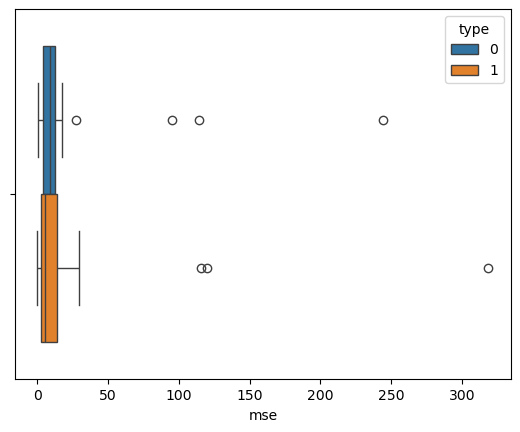

In [109]:
sns.boxplot(data = general_metrics, x = "mse", hue = "type")

<Axes: xlabel='mape'>

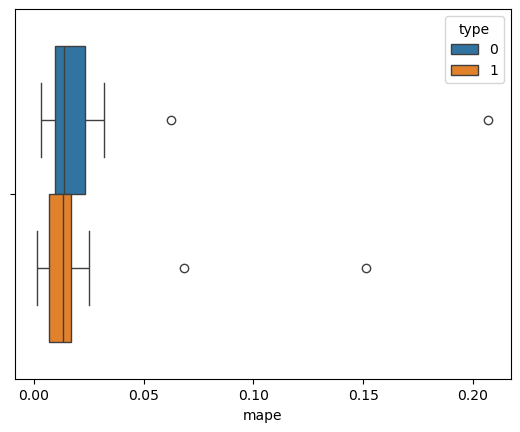

In [93]:
sns.boxplot(data = general_metrics, x = "mape", hue = "type")

<Axes: xlabel='r2'>

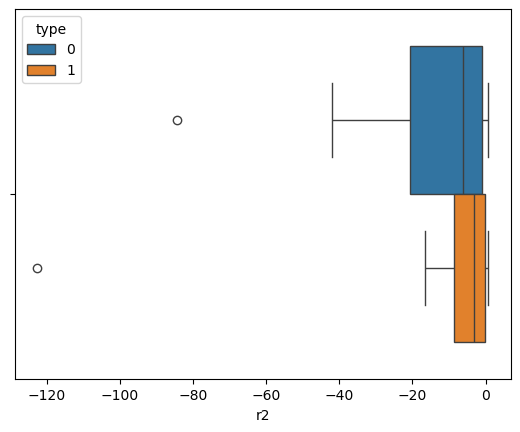

In [94]:
sns.boxplot(data = general_metrics, x = "r2", hue = "type")

## 30 min

In [ ]:
m_d0 = np.array(metrics_d0_30min)
m_d1 = np.array(metrics_d1_30min)
l = len(m_d0)
zeros = [0 for i in range(l)]
ones = [1 for i in range(l)]
df_d0 = pd.DataFrame({
    "type" : zeros,
    "mse" : m_d0[:,0],
    "mape" : m_d0[:,1],
    "r2" : m_d0[:,2],
})
df_d1 = pd.DataFrame({
    "type" : ones,
    "mse" : m_d1[:,0],
    "mape" : m_d1[:,1],
    "r2" : m_d1[:,2],
})

general_metrics_30min = pd.concat([df_d0, df_d1])